# HTC

**HTC** steht für **Heat Transfer Coefficient**.

Beschreibt:

> **Wie stark eine Oberfläche Wärme mit ihrer Umgebung austauscht.**

# Randbedingug
Beschreibt, was an der Oberfläche eines Körpers thermisch passiert.

## HTC Formel:

$$
htc_{agg} = \frac{q_{summe}}{kontaktflaeche_{summe} \cdot t_{flaechengewichtet}}
$$

mit:
- `q_summe` = aggregierter Wärmestrom
- `kontaktflaeche_summe` = aggregierte Fläche
- `t_flaechengewichtet` = flächengewichtete Temperaturdifferenz

# 1. Daten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error


df = pd.read_csv("region_zeit_aggregation.csv")
display(df.head())
display(df.columns)

,case,element,region_group,time_s,anzahl_punkte,t_mean,t_flaechen_summe,kontaktflaeche_summe,q_summe,q_dot_avg_mean,t_flaechengewichtet
0,Case1,Element1,bottom_surface,10.0,30389,0.000320,0.000016,0.04784,-0.000005,-0.000230,0.000340
1,Case1,Element1,bottom_surface,13.0,30389,0.000388,0.000020,0.04784,0.000009,-0.000020,0.000413
2,Case1,Element1,bottom_surface,17.0,30389,0.000476,0.000024,0.04784,0.000035,0.000408,0.000507
3,Case1,Element1,bottom_surface,22.0,30389,0.000586,0.000030,0.04784,0.000078,0.001138,0.000623
4,Case1,Element1,bottom_surface,28.0,30389,0.000719,0.000037,0.04784,0.000136,0.002133,0.000763


Index(['case', 'element', 'region_group', 'time_s', 'anzahl_punkte', 't_mean',
       't_flaechen_summe', 'kontaktflaeche_summe', 'q_summe', 'q_dot_avg_mean',
       't_flaechengewichtet'],
      dtype='str')

# 2. viel zu htc

In [2]:
df_htc = df.copy()

# Kleine Temperaturdifferenzen vermeiden,
# weil sonst HTC extrem groß oder unendlich wird
schwelle_t = 1e-4

gueltig = (
    (df_htc["kontaktflaeche_summe"] > 0) &
    (df_htc["t_flaechengewichtet"].abs() > schwelle_t)
)

# HTC mit Vorzeichen
# Das Vorzeichen zeigt die Richtung des Wärmeübergangs
df_htc["htc_agg"] = np.where(
    gueltig,
    df_htc["q_summe"] / (
        df_htc["kontaktflaeche_summe"] * df_htc["t_flaechengewichtet"]
    ),
    np.nan
)

# Unendliche Werte entfernen
df_htc["htc_agg"] = df_htc["htc_agg"].replace([np.inf, -np.inf], np.nan)

# HTC als Betrag
# Diese Spalte eignet sich besser für Vergleich, Mittelwertbildung und Curve Fitting
df_htc["htc_agg_abs"] = df_htc["htc_agg"].abs()

# Kurzer Check
print("Anzahl Zeilen gesamt:", len(df_htc))
print("Anzahl gültige HTC-Werte:", df_htc["htc_agg"].notna().sum())
print("Anzahl ungültige HTC-Werte:", df_htc["htc_agg"].isna().sum())

print("Negative HTC-Werte:", (df_htc["htc_agg"] < 0).sum())
print("Positive HTC-Werte:", (df_htc["htc_agg"] > 0).sum())

display(df_htc[[
    "case",
    "element",
    "region_group",
    "time_s",
    "q_summe",
    "kontaktflaeche_summe",
    "t_flaechengewichtet",
    "htc_agg",
    "htc_agg_abs"
]].head())

display(df_htc[["htc_agg", "htc_agg_abs"]].describe())

Anzahl Zeilen gesamt: 2520
Anzahl gültige HTC-Werte: 2396
Anzahl ungültige HTC-Werte: 124
Negative HTC-Werte: 1831
Positive HTC-Werte: 565


,case,element,region_group,time_s,q_summe,kontaktflaeche_summe,t_flaechengewichtet,htc_agg,htc_agg_abs
0,Case1,Element1,bottom_surface,10.0,-0.000005,0.04784,0.000340,-0.296138,0.296138
1,Case1,Element1,bottom_surface,13.0,0.000009,0.04784,0.000413,0.435809,0.435809
2,Case1,Element1,bottom_surface,17.0,0.000035,0.04784,0.000507,1.429090,1.429090
3,Case1,Element1,bottom_surface,22.0,0.000078,0.04784,0.000623,2.610938,2.610938
4,Case1,Element1,bottom_surface,28.0,0.000136,0.04784,0.000763,3.731643,3.731643


,htc_agg,htc_agg_abs
count,2396.000000,2396.000000
mean,-87.602300,94.413687
std,241.057435,238.470937
min,-2044.101710,0.004232
25%,-72.220357,1.508050
50%,-2.188252,4.652755
75%,-0.081069,74.978375
max,177.127753,2044.101710


# 3. in Heat-up / Cooldown einteilen

In [3]:
heatup_cases = ["Case1", "Case3", "Case5", "Case6", "Case7"]
cooldown_cases = ["Case2", "Case4"]

df_htc["phase"] = np.select(
    [
        df_htc["case"].isin(heatup_cases),
        df_htc["case"].isin(cooldown_cases)
    ],
    [
        "heatup",
        "cooldown"
    ],
    default="unknown"
)

display(df_htc[["case", "phase"]].drop_duplicates().sort_values("case"))

,case,phase
0,Case1,heatup
360,Case2,cooldown
720,Case3,heatup
1080,Case4,cooldown
1440,Case5,heatup
1800,Case6,heatup
2160,Case7,heatup


# 4. Plotten

,phase,element,region_group,case
369,cooldown,Element1,bottom_surface,Case2
1089,cooldown,Element1,bottom_surface,Case4
399,cooldown,Element1,lateral,Case2
1119,cooldown,Element1,lateral,Case4
429,cooldown,Element1,support,Case2
...,...,...,...,...
339,heatup,Element3,top_surface,Case1
1059,heatup,Element3,top_surface,Case3
1779,heatup,Element3,top_surface,Case5
2139,heatup,Element3,top_surface,Case6


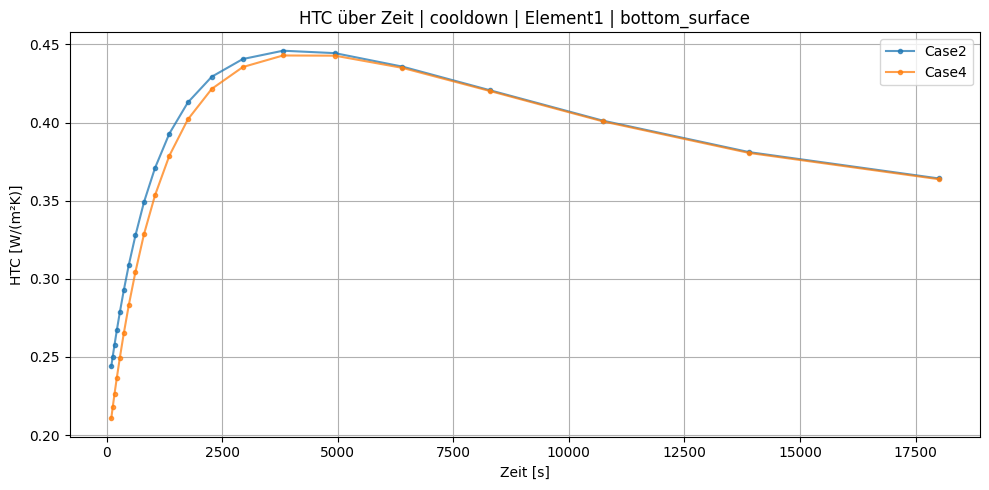

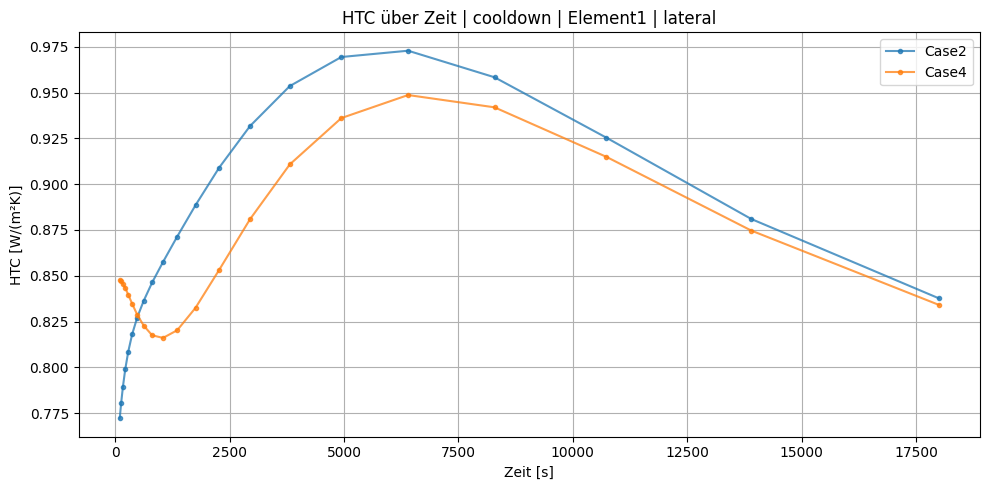

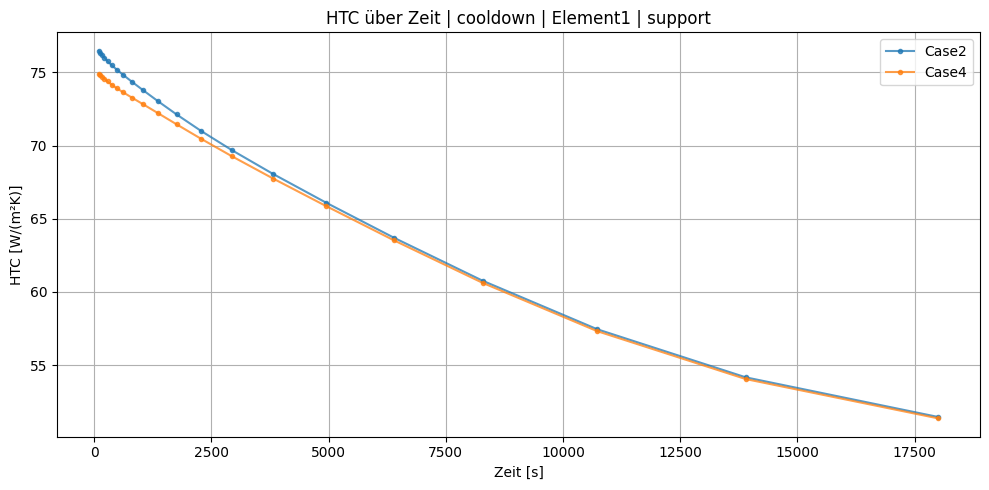

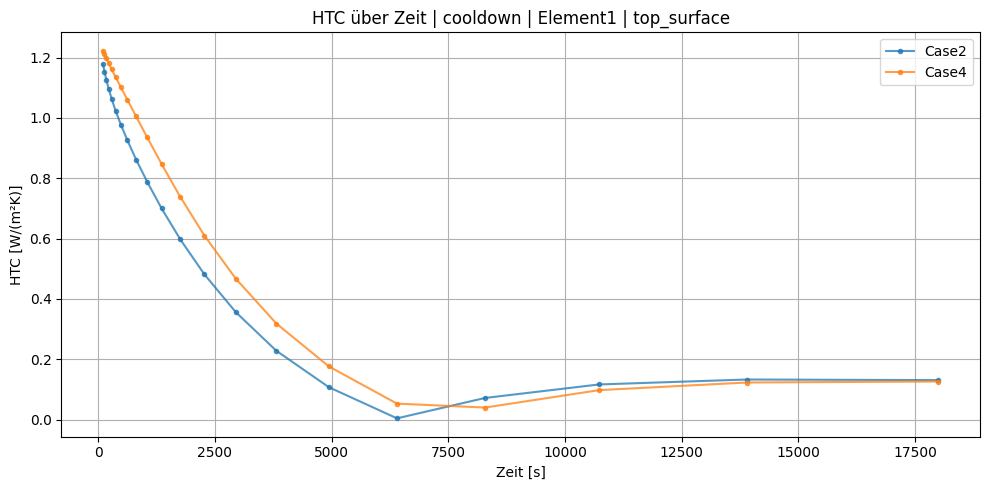

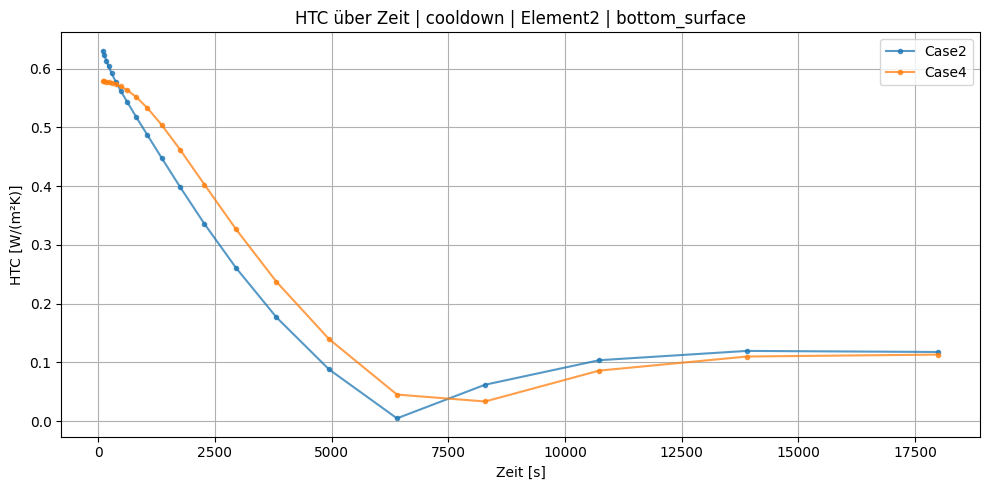

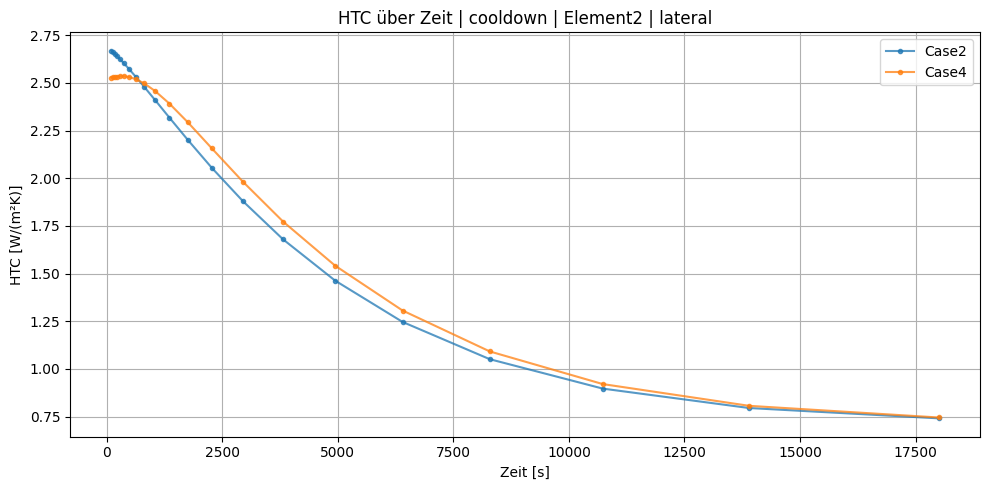

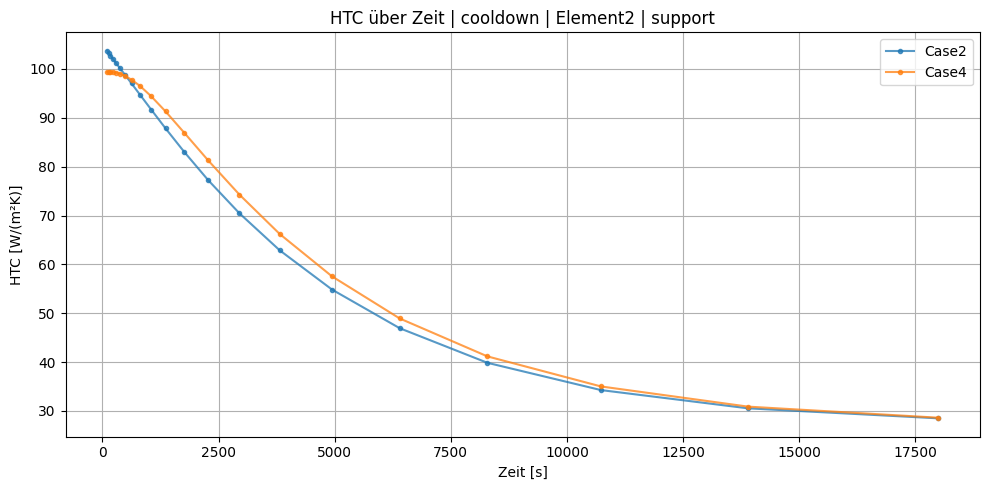

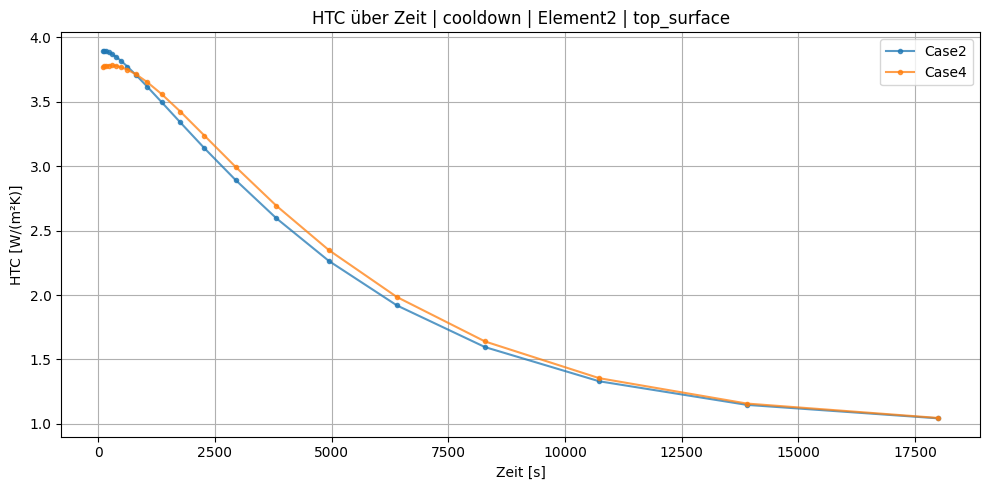

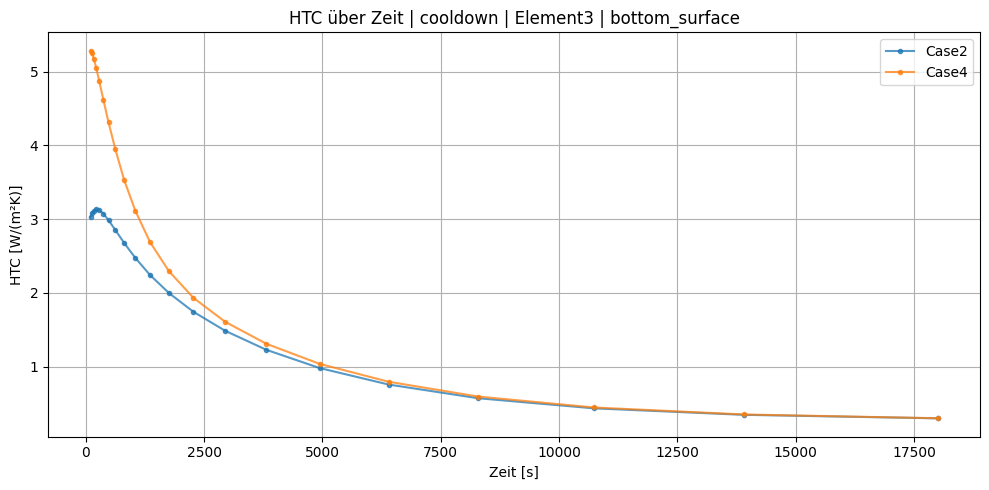

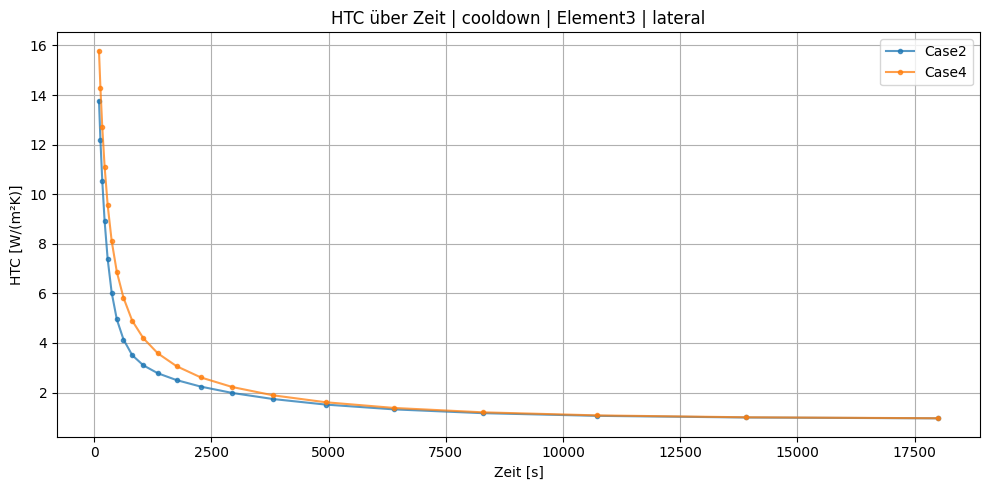

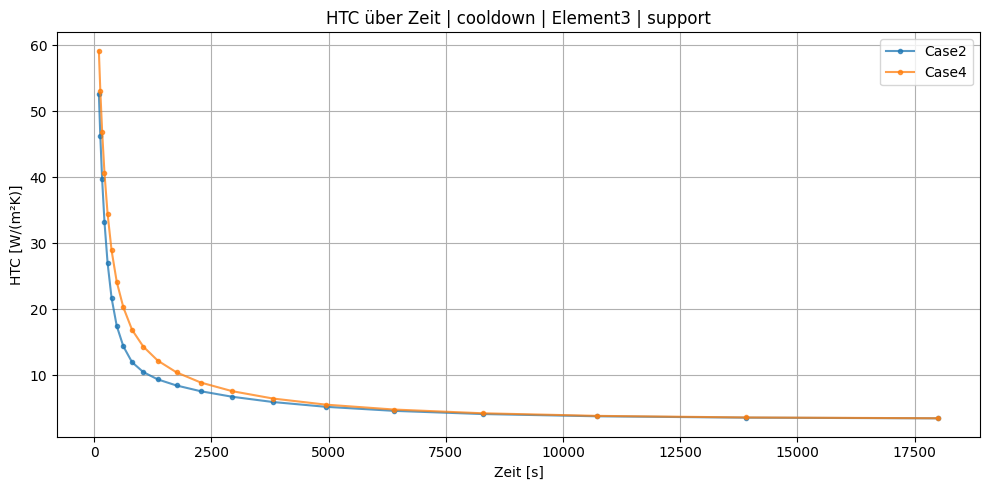

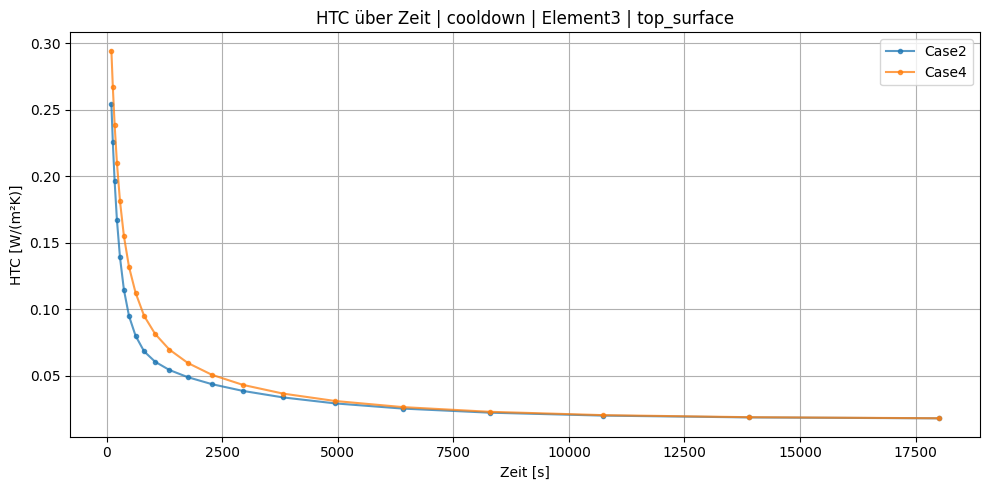

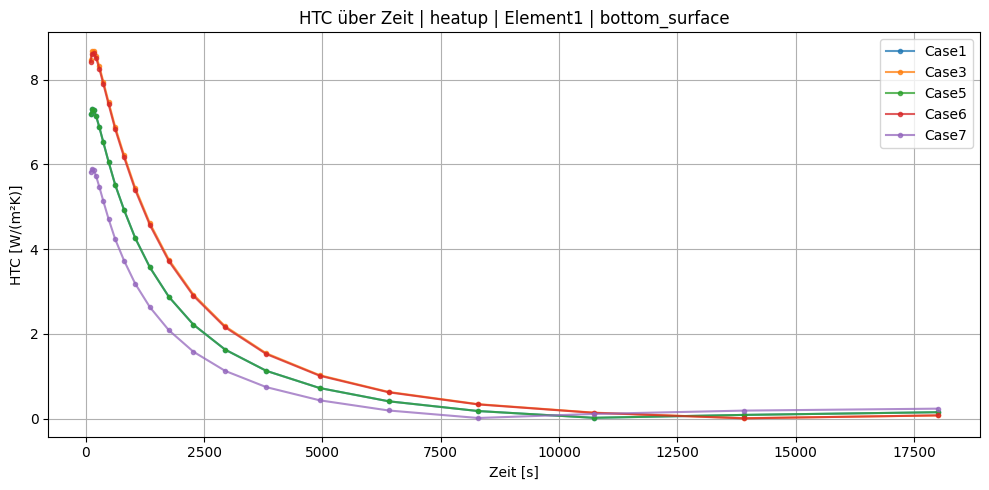

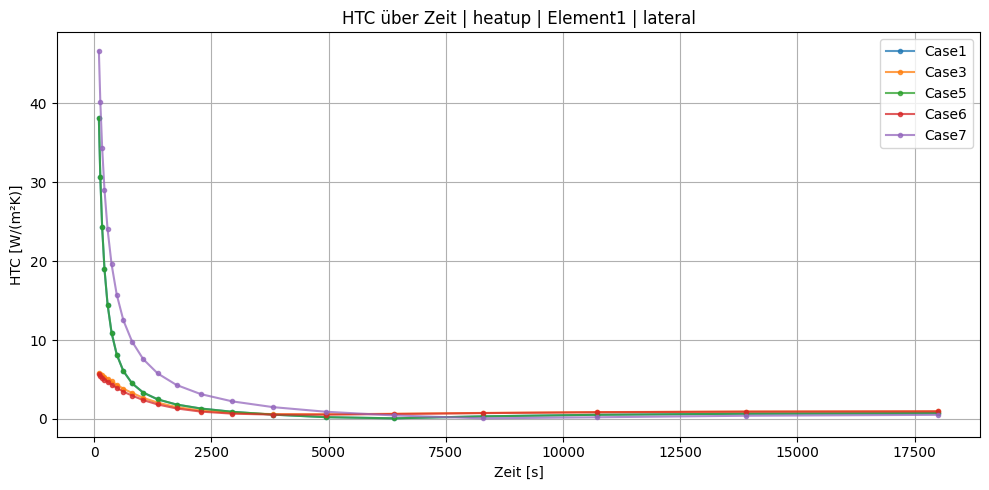

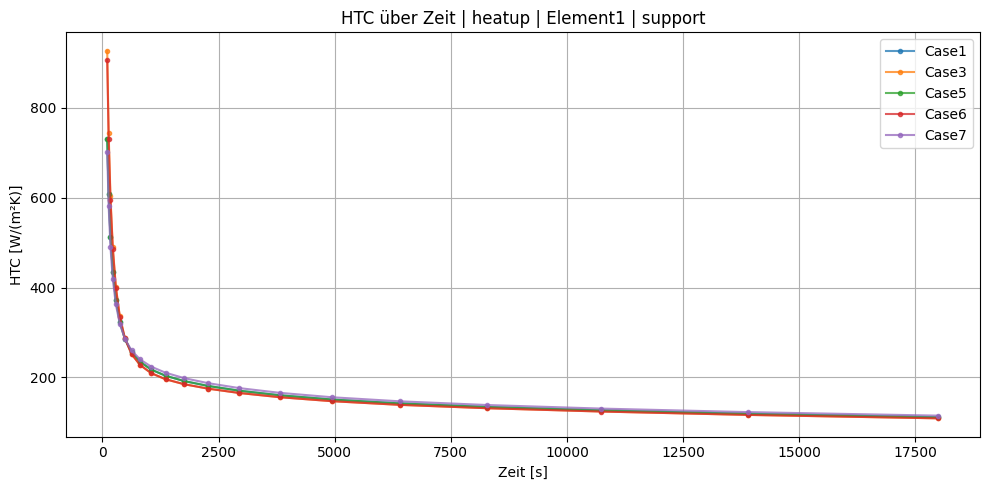

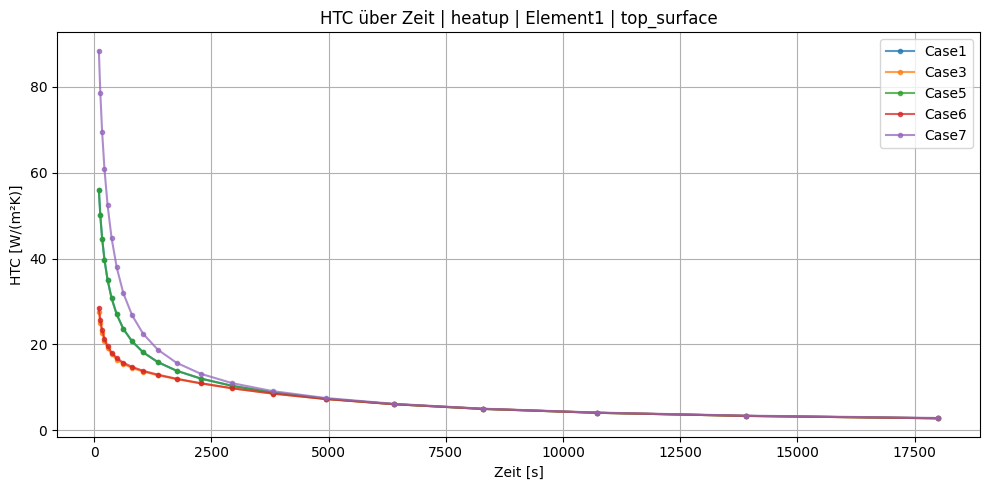

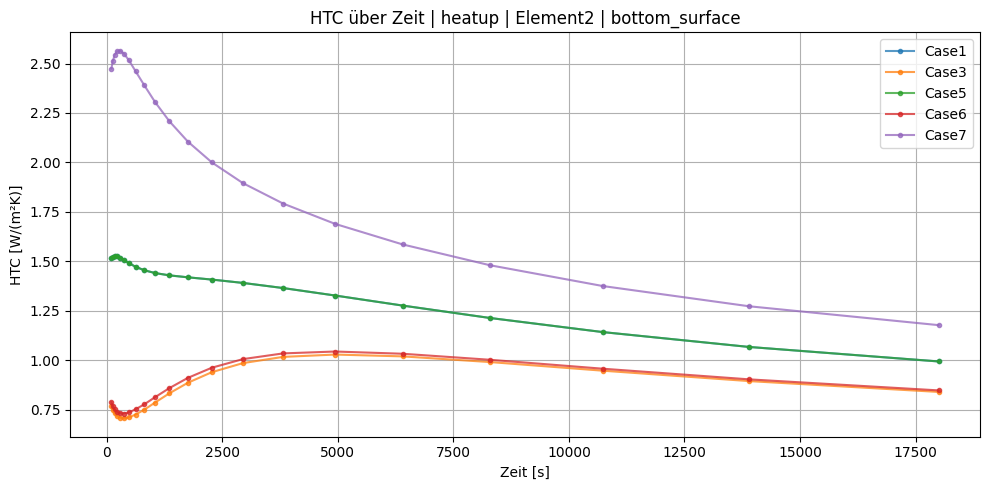

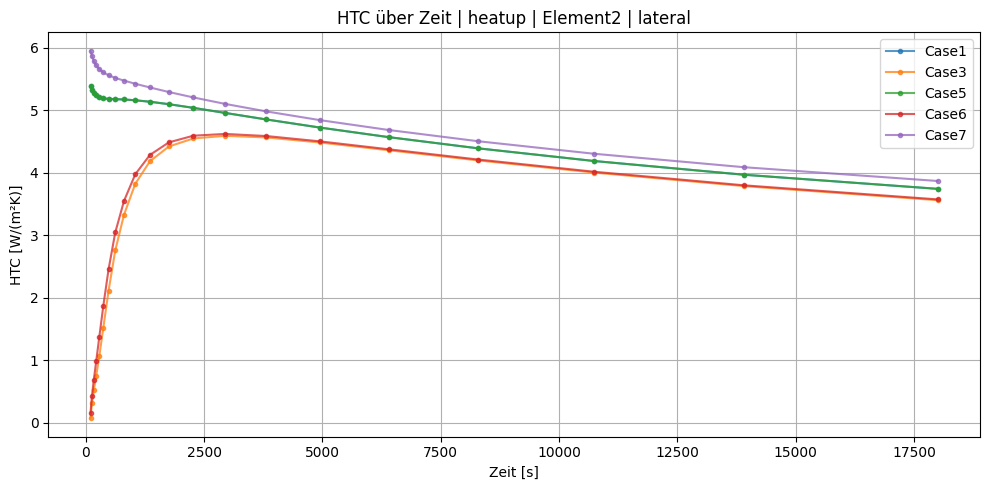

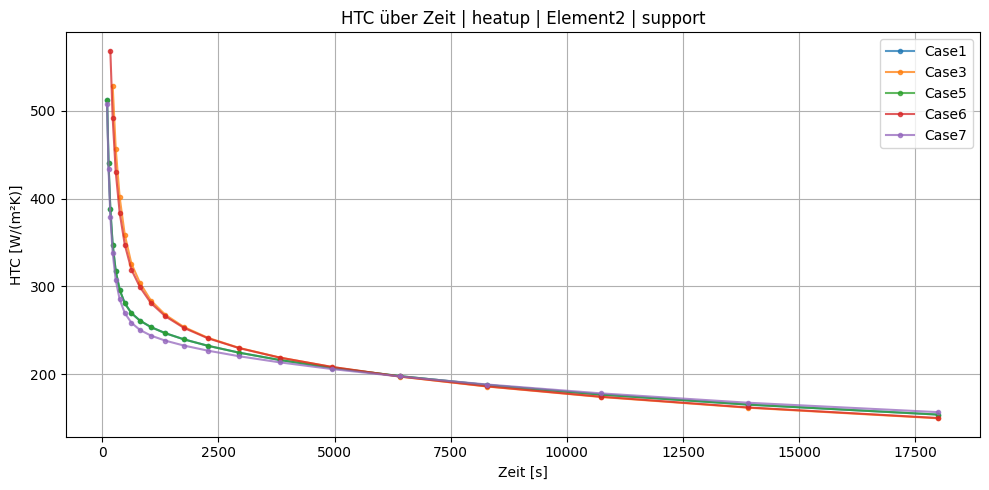

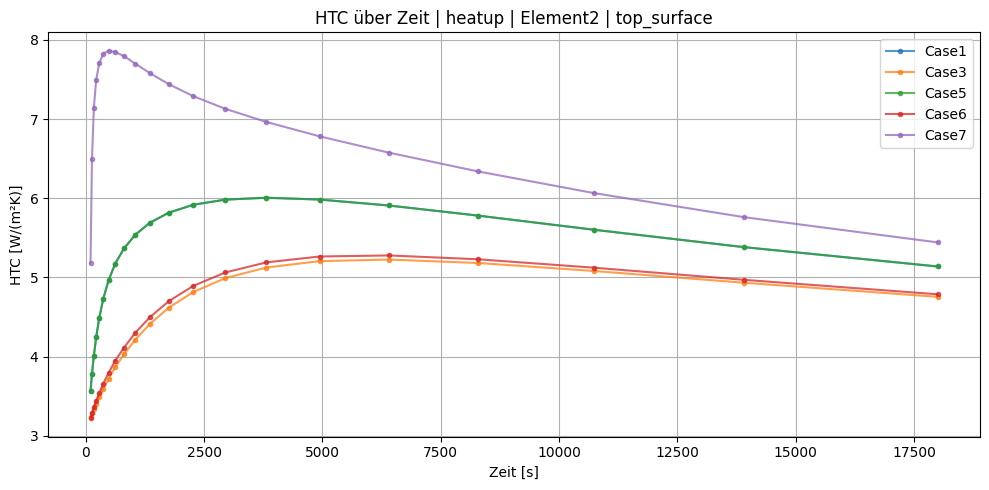

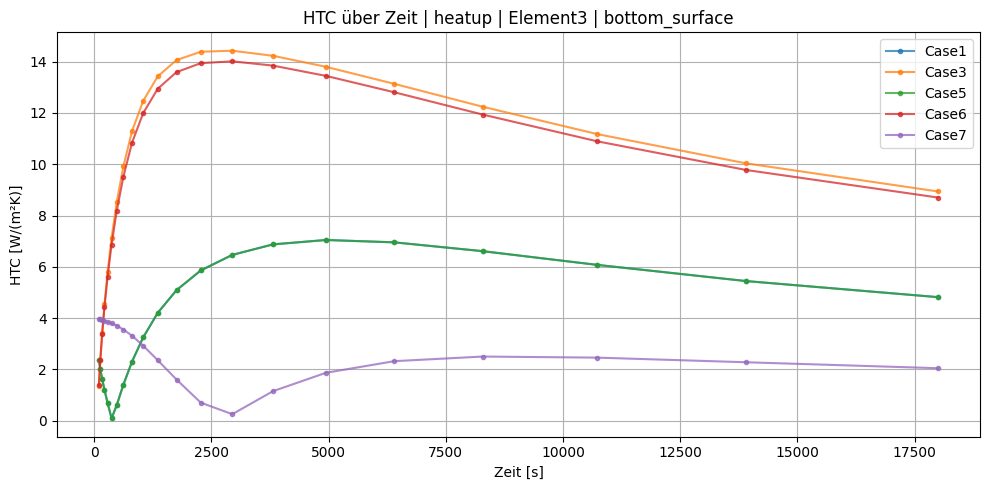

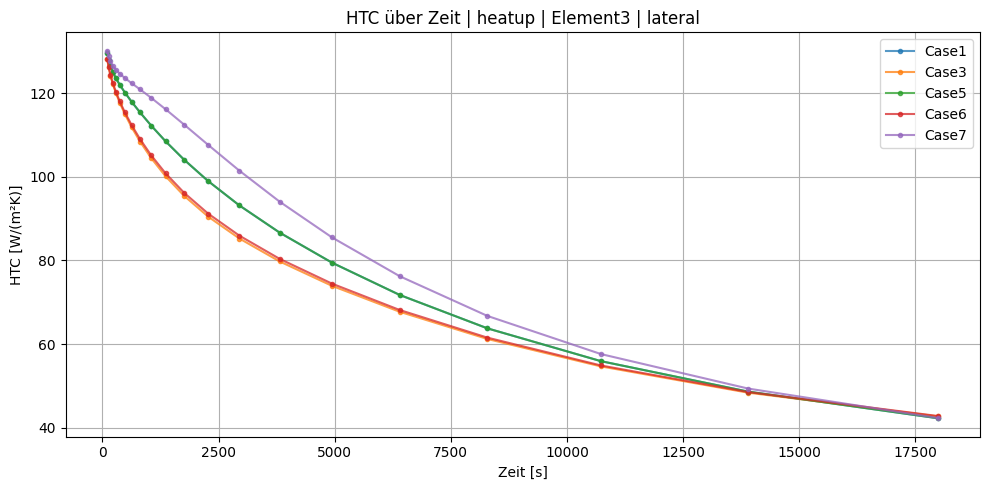

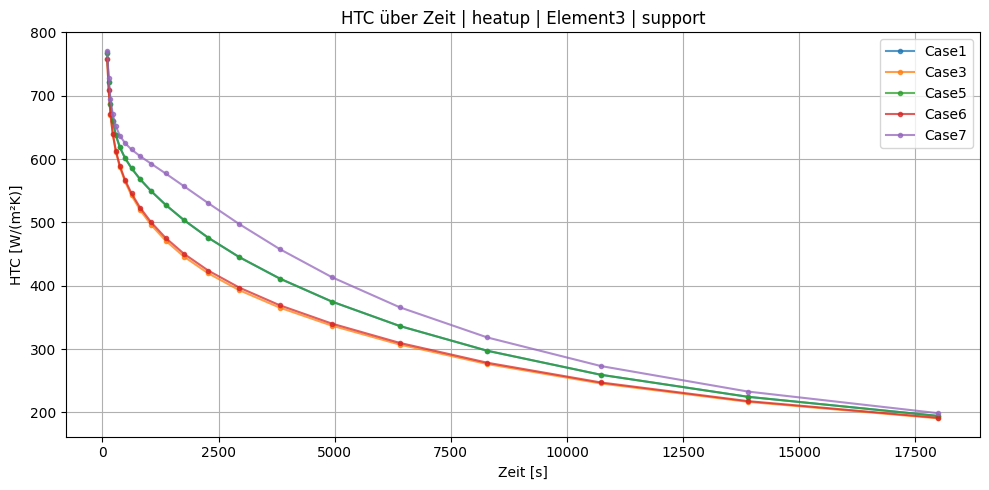

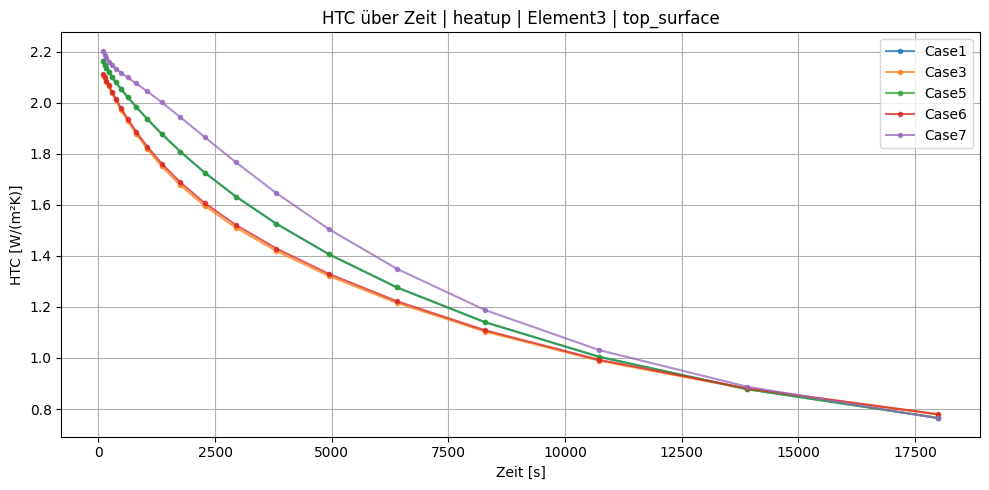

In [4]:
time_min = 100

df_plot = df_htc[
    (df_htc["time_s"] >= time_min) &
    (df_htc["phase"].isin(["heatup", "cooldown"]))
].dropna(subset=["htc_agg_abs"]).copy()

# Übersicht: Welche Kombinationen gibt es?
display(
    df_plot[["phase", "element", "region_group", "case"]]
    .drop_duplicates()
    .sort_values(["phase", "element", "region_group", "case"])
)

# Plot für jede Kombination aus Phase, Element und Region
for (phase, element, region), df_group in df_plot.groupby(["phase", "element", "region_group"]):
    
    plt.figure(figsize=(10, 5))
    
    for case_name in sorted(df_group["case"].unique()):
        df_case = df_group[df_group["case"] == case_name].sort_values("time_s")
        
        plt.plot(
            df_case["time_s"],
            df_case["htc_agg_abs"],
            marker=".",
            linewidth=1.5,
            alpha=0.75,
            label=case_name
        )
    
    plt.title(f"HTC über Zeit | {phase} | {element} | {region}")
    plt.xlabel("Zeit [s]")
    plt.ylabel("HTC [W/(m²K)]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 5. Generalisierte Mittelwertkurve berechnen

In [5]:
df_generalized_phase = (
    df_htc
    .dropna(subset=["htc_agg_abs"])
    .query("phase in ['heatup', 'cooldown']")
    .groupby(["phase", "element", "region_group", "time_s"], as_index=False)
    .agg(
        htc_mean=("htc_agg_abs", "mean"),
        htc_std=("htc_agg_abs", "std"),
        htc_min=("htc_agg_abs", "min"),
        htc_max=("htc_agg_abs", "max"),
        n_cases=("case", "nunique")
    )
)

display(df_generalized_phase.head())

,phase,element,region_group,time_s,htc_mean,htc_std,htc_min,htc_max,n_cases
0,cooldown,Element1,bottom_surface,10.0,0.207275,0.025462,0.189271,0.225279,2
1,cooldown,Element1,bottom_surface,13.0,0.207568,0.025457,0.189567,0.225569,2
2,cooldown,Element1,bottom_surface,17.0,0.208162,0.025434,0.190178,0.226147,2
3,cooldown,Element1,bottom_surface,22.0,0.209096,0.025379,0.191150,0.227042,2
4,cooldown,Element1,bottom_surface,28.0,0.210380,0.025280,0.192504,0.228256,2


# 6. Fehler berechnen

In [6]:
time_min = 100

df_eval = df_htc[
    (df_htc["time_s"] >= time_min) &
    (df_htc["phase"].isin(["heatup", "cooldown"]))
].dropna(subset=["htc_agg_abs"]).copy()

results = []

for (phase, element, region, case_name), df_case in df_eval.groupby(
    ["phase", "element", "region_group", "case"]
):
    
    df_case = df_case.sort_values("time_s").copy()
    
    df_mean = df_generalized_phase[
        (df_generalized_phase["phase"] == phase) &
        (df_generalized_phase["element"] == element) &
        (df_generalized_phase["region_group"] == region)
    ][["time_s", "htc_mean"]].copy()
    
    df_merged = df_case.merge(df_mean, on="time_s", how="inner")
    
    if len(df_merged) < 3:
        continue
    
    y_true = df_merged["htc_agg_abs"].values
    y_pred = df_merged["htc_mean"].values
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    mean_abs_htc = np.mean(np.abs(y_true))
    
    if mean_abs_htc > 0:
        rel_mae = mae / mean_abs_htc * 100
    else:
        rel_mae = np.nan
    
    results.append({
        "phase": phase,
        "element": element,
        "region_group": region,
        "case": case_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "rel_MAE_%": rel_mae,
        "n_points": len(df_merged),
        "htc_mean_abs": mean_abs_htc
    })

df_fehler_phase = pd.DataFrame(results)

display(
    df_fehler_phase
    .sort_values(["phase", "element", "region_group", "case"])
)

,phase,element,region_group,case,MAE,MSE,RMSE,rel_MAE_%,n_points,htc_mean_abs
0,cooldown,Element1,bottom_surface,Case2,0.007536,0.000096,0.009773,2.105439,21,0.357919
1,cooldown,Element1,bottom_surface,Case4,0.007536,0.000096,0.009773,2.197994,21,0.342848
2,cooldown,Element1,lateral,Case2,0.017293,0.000412,0.020297,1.991679,21,0.868284
3,cooldown,Element1,lateral,Case4,0.017293,0.000412,0.020297,2.007426,21,0.861473
4,cooldown,Element1,support,Case2,0.402022,0.234434,0.484183,0.577489,21,69.615572
...,...,...,...,...,...,...,...,...,...,...
79,heatup,Element3,top_surface,Case1,0.014504,0.000260,0.016136,0.851098,21,1.704152
80,heatup,Element3,top_surface,Case3,0.060464,0.004703,0.068580,3.707789,21,1.630736
81,heatup,Element3,top_surface,Case5,0.014504,0.000260,0.016136,0.851099,21,1.704152
82,heatup,Element3,top_surface,Case6,0.054143,0.003769,0.061392,3.307032,21,1.637219


# 7. Entscheidungstabelle

In [7]:
def bewerte_rel_fehler(rel_mae):
    if rel_mae < 5:
        return "sehr gut"
    elif rel_mae < 15:
        return "brauchbar"
    elif rel_mae < 30:
        return "kritisch"
    else:
        return "nicht gut"

df_generalization_summary = (
    df_fehler_phase
    .groupby(["phase", "element", "region_group"], as_index=False)
    .agg(
        rel_MAE_mean=("rel_MAE_%", "mean"),
        rel_MAE_max=("rel_MAE_%", "max"),
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        n_cases=("case", "nunique")
    )
)

df_generalization_summary["bewertung"] = df_generalization_summary["rel_MAE_mean"].apply(bewerte_rel_fehler)

display(df_generalization_summary.sort_values(["phase", "element", "region_group"]))

,phase,element,region_group,rel_MAE_mean,rel_MAE_max,MAE_mean,RMSE_mean,n_cases,bewertung
0,cooldown,Element1,bottom_surface,2.151717,2.197994,0.007536,0.009773,2,sehr gut
1,cooldown,Element1,lateral,1.999552,2.007426,0.017293,0.020297,2,sehr gut
2,cooldown,Element1,support,0.580863,0.584236,0.402022,0.484183,2,sehr gut
3,cooldown,Element1,top_surface,6.529930,6.924295,0.043256,0.049061,2,brauchbar
4,cooldown,Element2,bottom_surface,4.700050,4.780673,0.017913,0.020663,2,sehr gut
5,cooldown,Element2,lateral,1.733125,1.733806,0.034823,0.040282,2,sehr gut
6,cooldown,Element2,support,1.511366,1.517587,1.164956,1.350973,2,sehr gut
7,cooldown,Element2,top_surface,1.119500,1.119664,0.033569,0.038552,2,sehr gut
8,cooldown,Element3,bottom_surface,17.356441,20.283240,0.401991,0.573232,2,kritisch
9,cooldown,Element3,lateral,10.355648,11.416782,0.504125,0.672053,2,brauchbar


# 8. Curve Fit machen

In [8]:
# Fit-Funktion
# c ist der spätere stationäre Wert
# a1, b1, a2, b2 beschreiben schnelles und langsames Abklingen/Ansteigen
def double_exponential(t, a1, b1, a2, b2, c):
    return a1 * np.exp(-b1 * t) + a2 * np.exp(-b2 * t) + c


time_min = 100

df_fit_input = df_generalized_phase[
    (df_generalized_phase["time_s"] >= time_min) &
    (df_generalized_phase["phase"].isin(["heatup", "cooldown"]))
].dropna(subset=["htc_mean"]).copy()

fit_results = []
fit_curves = []

for (phase, element, region), df_group in df_fit_input.groupby(["phase", "element", "region_group"]):
    
    df_group = df_group.sort_values("time_s").copy()
    
    t = df_group["time_s"].values.astype(float)
    y = df_group["htc_mean"].values.astype(float)
    
    if len(t) < 6:
        fit_results.append({
            "phase": phase,
            "element": element,
            "region_group": region,
            "fit_status": "too few points",
            "a1": np.nan,
            "b1": np.nan,
            "a2": np.nan,
            "b2": np.nan,
            "c": np.nan
        })
        continue
    
    # Zeit bei 0 starten lassen -> numerisch stabiler
    t0 = t.min()
    t_shift = t - t0
    
    y_start = y[0]
    y_end = y[-1]
    delta = y_start - y_end
    
    # Startwerte für curve_fit
    p0 = [
        0.7 * delta,
        0.01,
        0.3 * delta,
        0.001,
        y_end
    ]
    
    try:
        params, covariance = curve_fit(
            double_exponential,
            t_shift,
            y,
            p0=p0,
            bounds=(
                [-np.inf, 0, -np.inf, 0, -np.inf],
                [ np.inf, 1,  np.inf, 1,  np.inf]
            ),
            maxfev=100000
        )
        
        y_fit = double_exponential(t_shift, *params)
        
        a1, b1, a2, b2, c = params
        
        fit_results.append({
            "phase": phase,
            "element": element,
            "region_group": region,
            "fit_status": "ok",
            "a1": a1,
            "b1": b1,
            "a2": a2,
            "b2": b2,
            "c": c,
            "t0": t0,
            "n_points": len(t)
        })
        
        df_curve = pd.DataFrame({
            "phase": phase,
            "element": element,
            "region_group": region,
            "time_s": t,
            "time_shift": t_shift,
            "htc_mean": y,
            "htc_fit": y_fit
        })
        
        fit_curves.append(df_curve)
        
    except Exception as e:
        fit_results.append({
            "phase": phase,
            "element": element,
            "region_group": region,
            "fit_status": f"failed: {e}",
            "a1": np.nan,
            "b1": np.nan,
            "a2": np.nan,
            "b2": np.nan,
            "c": np.nan,
            "t0": t0,
            "n_points": len(t)
        })

df_fit_results = pd.DataFrame(fit_results)

if len(fit_curves) > 0:
    df_fit_curves = pd.concat(fit_curves, ignore_index=True)
else:
    df_fit_curves = pd.DataFrame()

display(df_fit_results.sort_values(["phase", "element", "region_group"]))
display(df_fit_curves.head())

,phase,element,region_group,fit_status,a1,b1,a2,b2,c,t0,n_points
0,cooldown,Element1,bottom_surface,ok,20.021639,0.002341,-20.208735,0.002327,0.417327,102.0,21
1,cooldown,Element1,lateral,ok,1.171854,0.001238,-1.270691,0.001123,0.918295,102.0,21
2,cooldown,Element1,support,ok,-4592.915587,0.000002,745.721766,0.000013,3922.671603,102.0,21
3,cooldown,Element1,top_surface,ok,-181.390642,0.000754,182.487533,0.000751,0.080977,102.0,21
4,cooldown,Element2,bottom_surface,ok,-124.705289,0.000747,125.221740,0.000744,0.074508,102.0,21
5,cooldown,Element2,lateral,ok,-0.577862,0.000856,2.476097,0.000231,0.701019,102.0,21
6,cooldown,Element2,support,ok,-14.103219,0.001033,88.622319,0.000229,27.004057,102.0,21
7,cooldown,Element2,top_surface,ok,-0.968091,0.000769,3.856256,0.000214,0.954955,102.0,21
8,cooldown,Element3,bottom_surface,ok,-0.073781,0.067600,3.790799,0.000452,0.438626,102.0,21
9,cooldown,Element3,lateral,ok,9.655223,0.005015,3.976117,0.000472,1.055114,102.0,21


,phase,element,region_group,time_s,time_shift,htc_mean,htc_fit
0,cooldown,Element1,bottom_surface,102.0,0.0,0.227369,0.230231
1,cooldown,Element1,bottom_surface,133.0,31.0,0.234015,0.235005
2,cooldown,Element1,bottom_surface,172.0,70.0,0.242042,0.241352
3,cooldown,Element1,bottom_surface,222.0,120.0,0.251879,0.249880
4,cooldown,Element1,bottom_surface,288.0,186.0,0.264167,0.261502


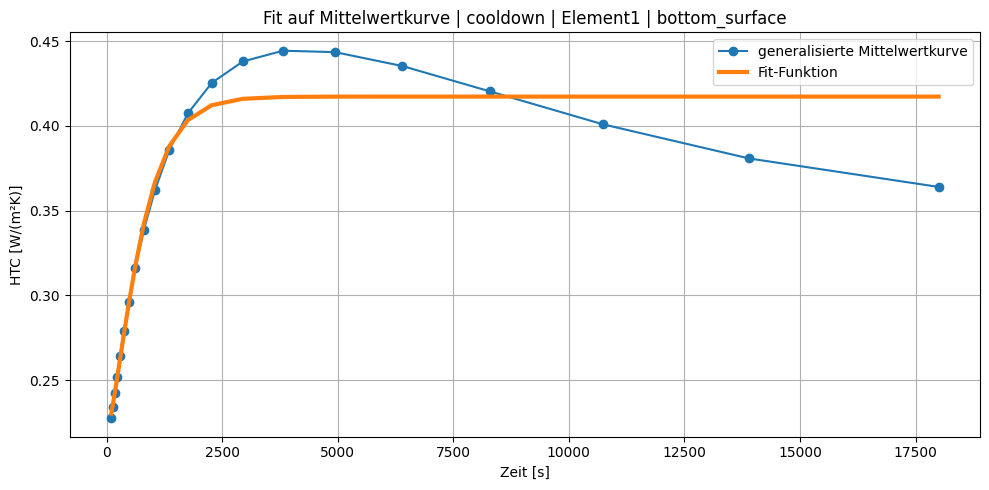

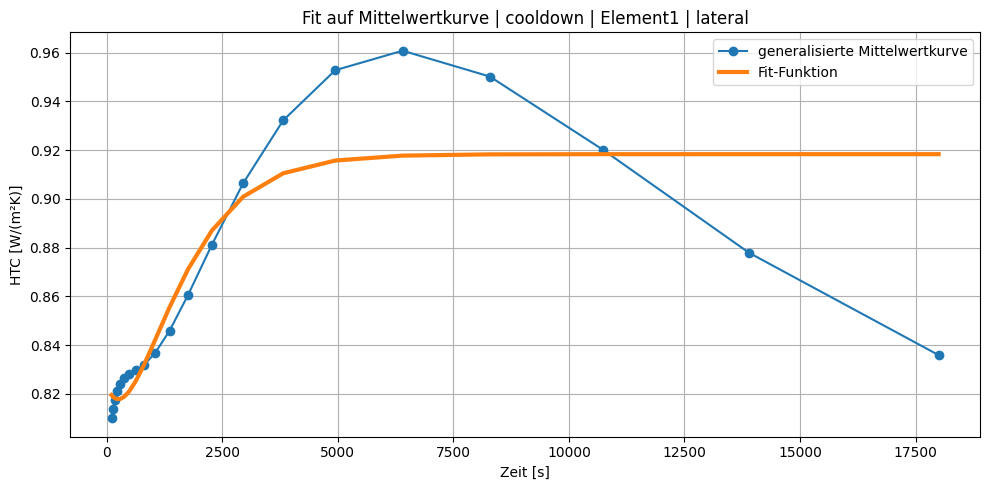

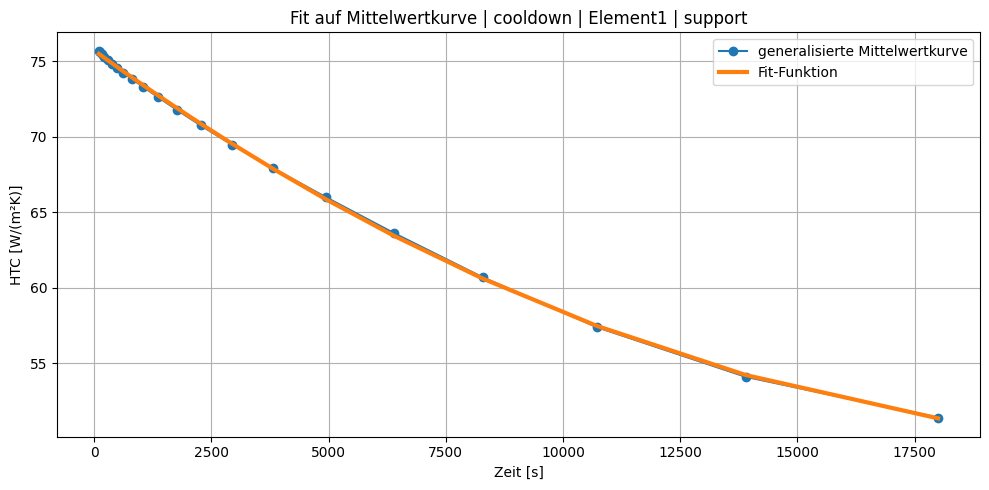

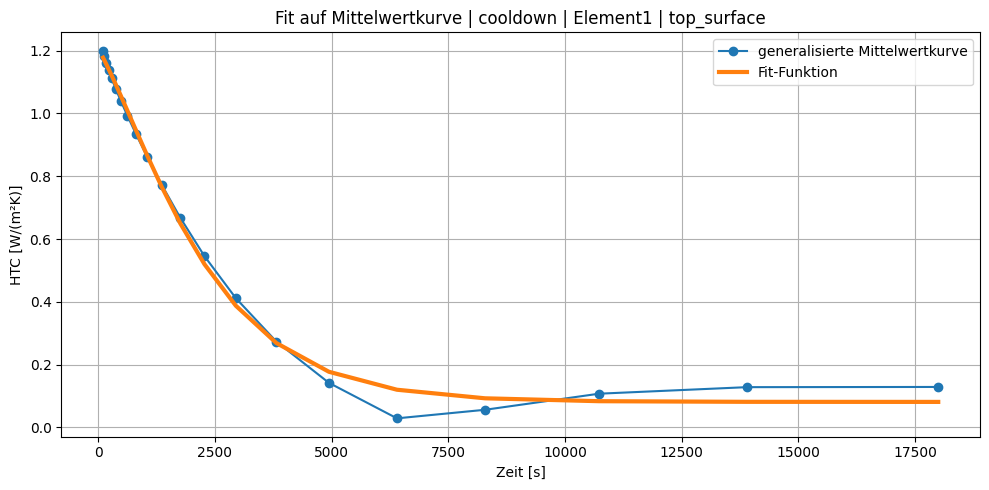

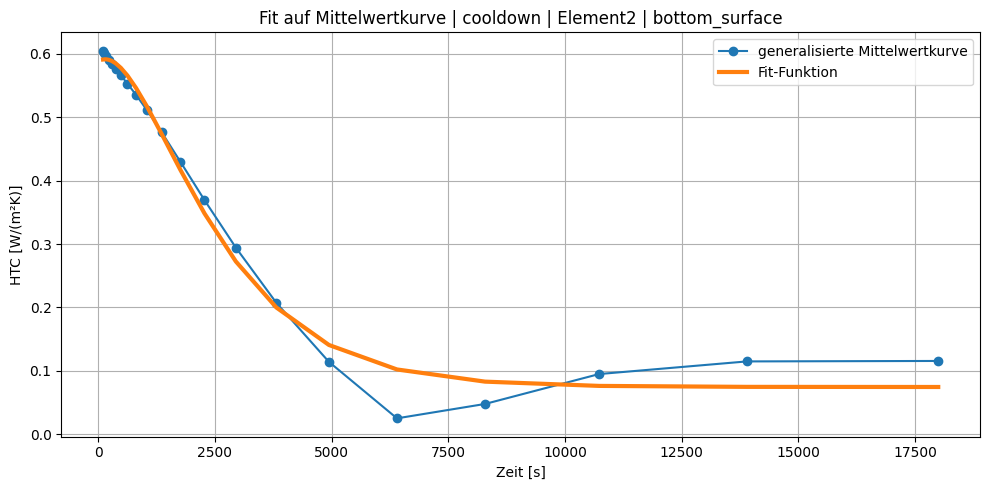

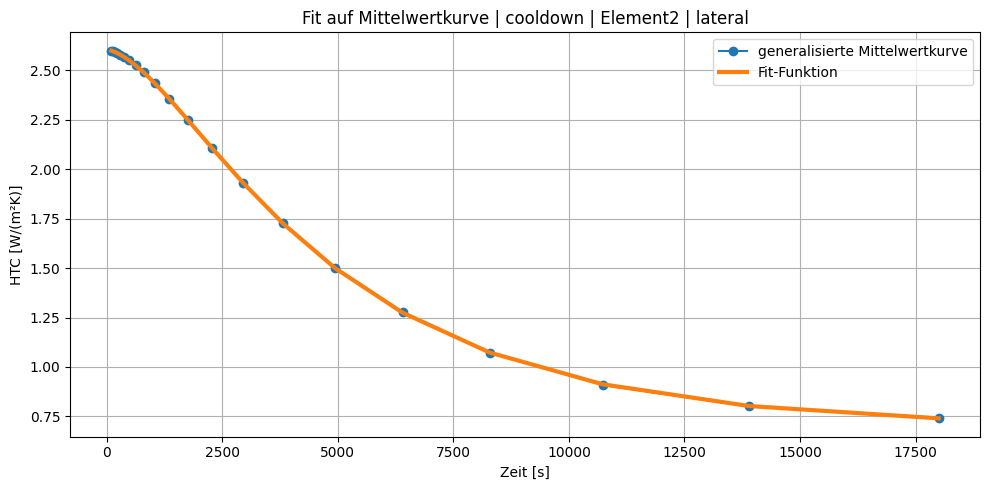

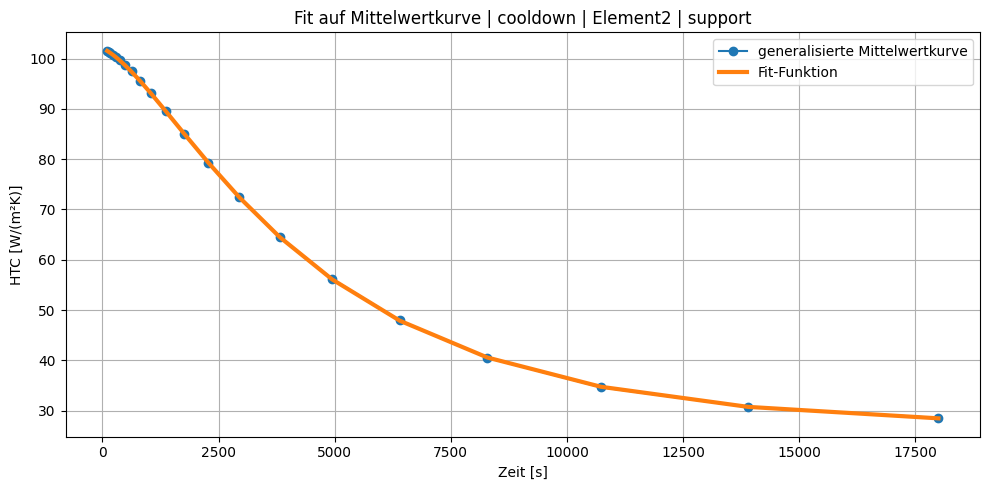

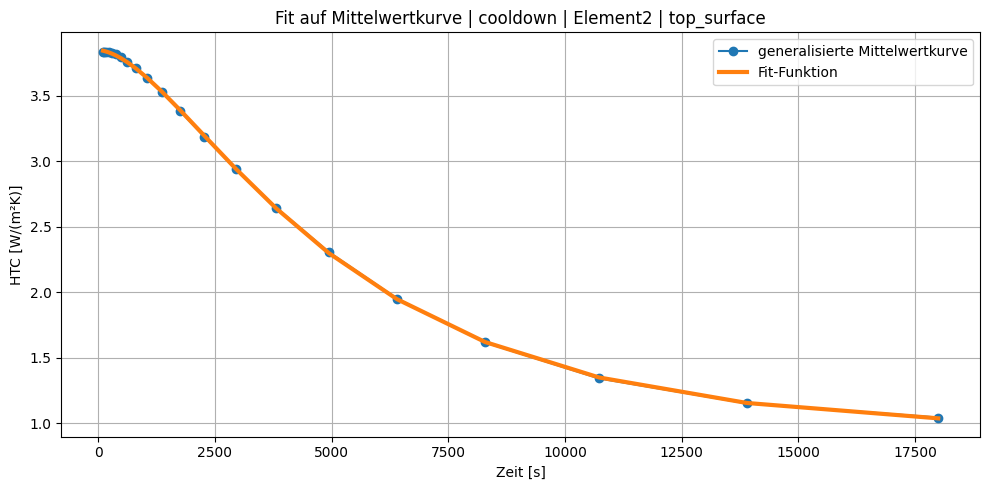

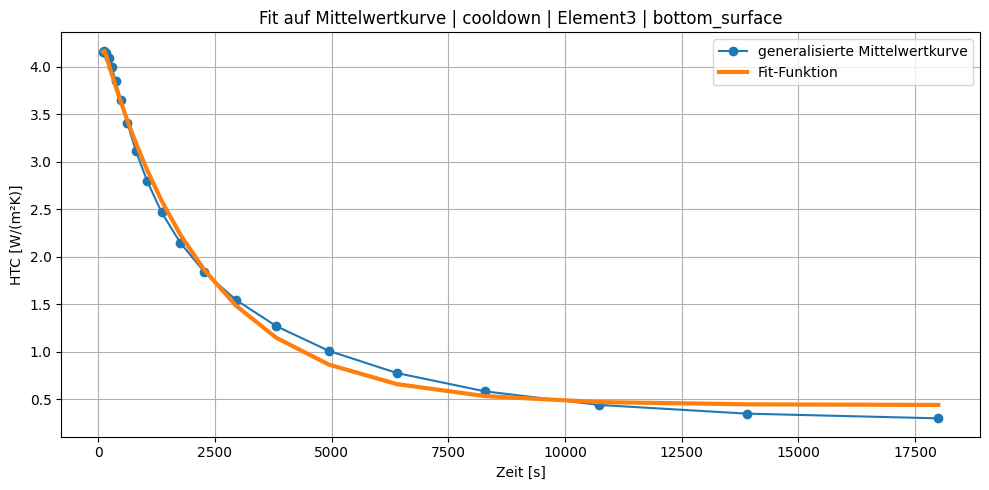

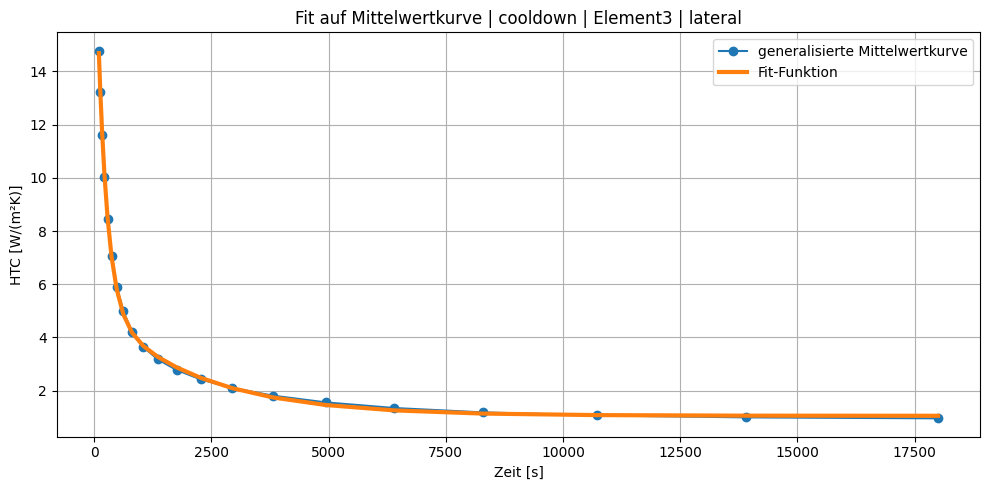

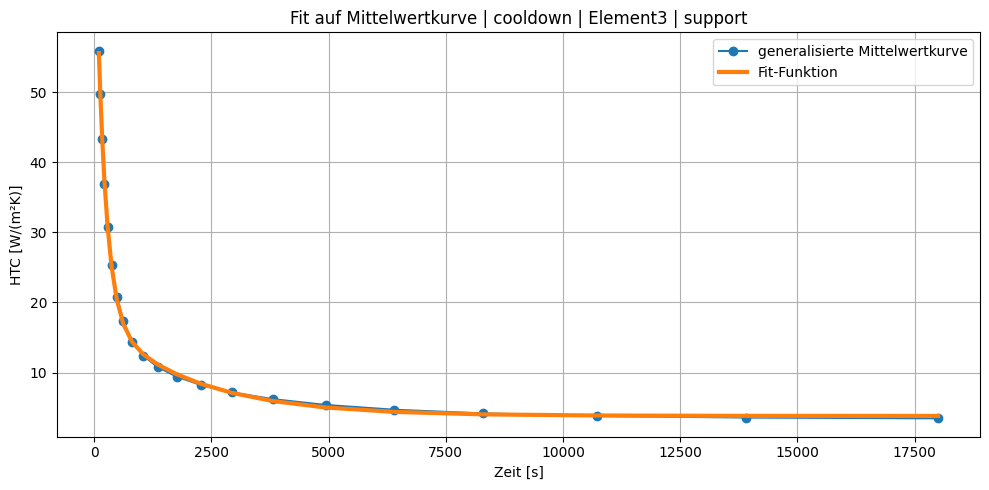

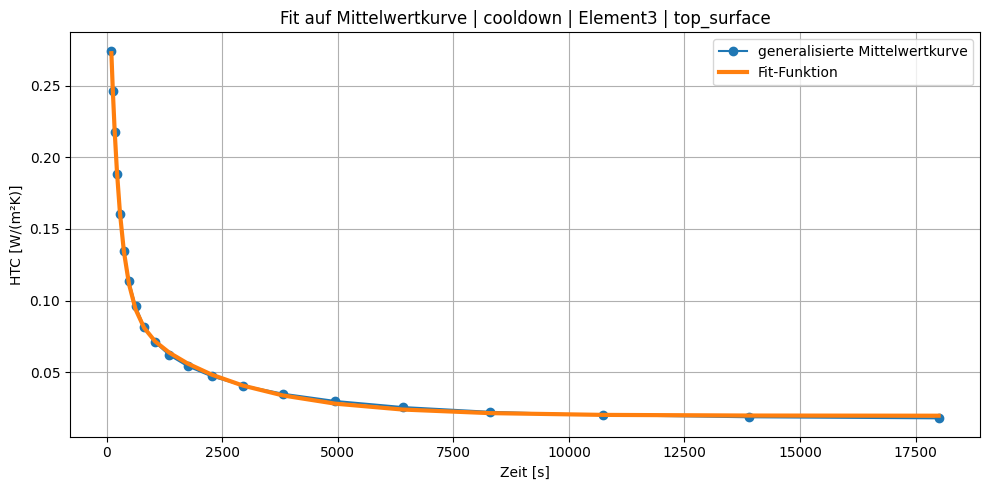

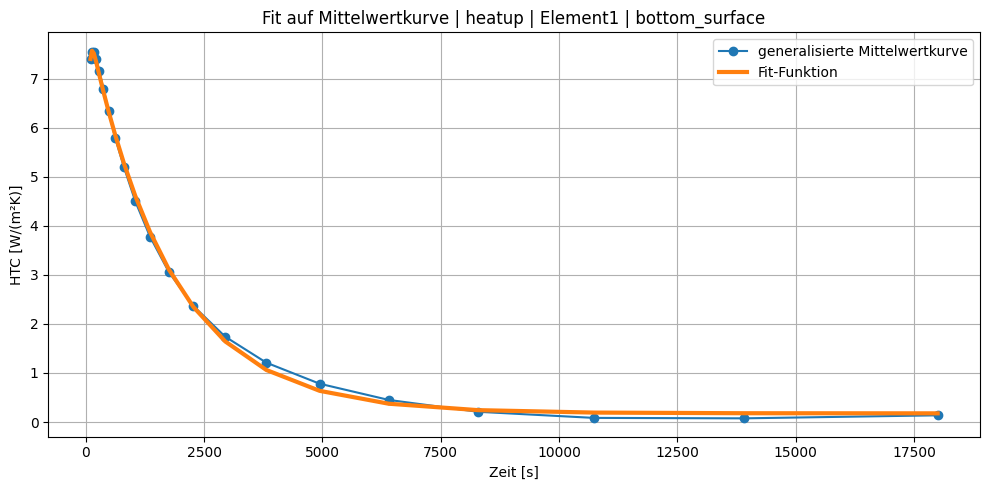

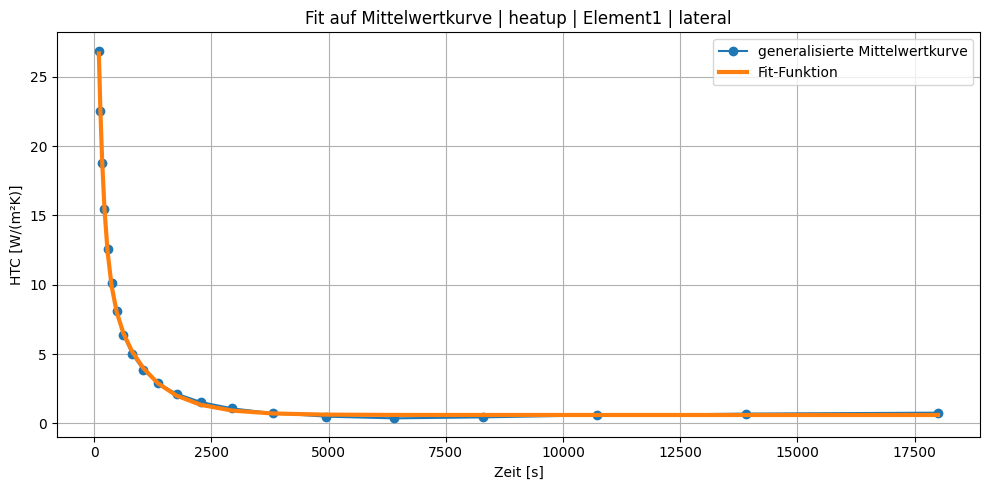

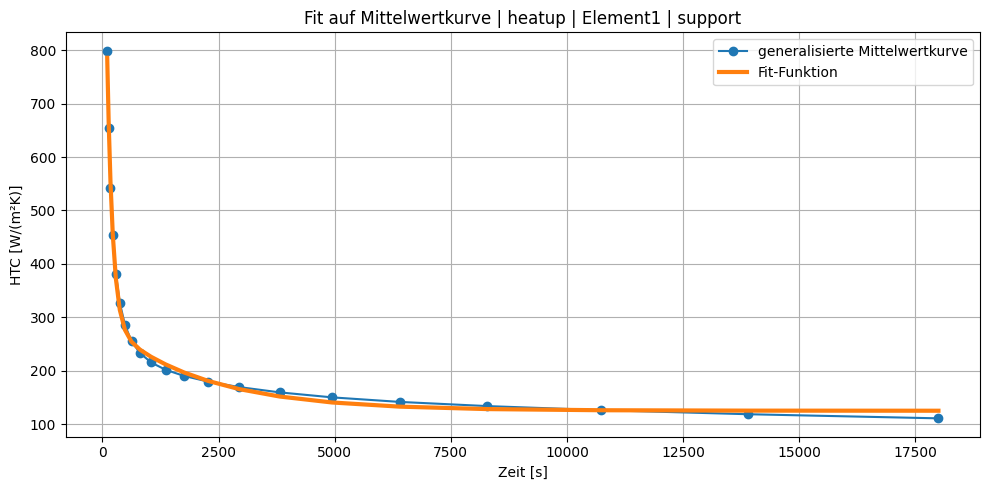

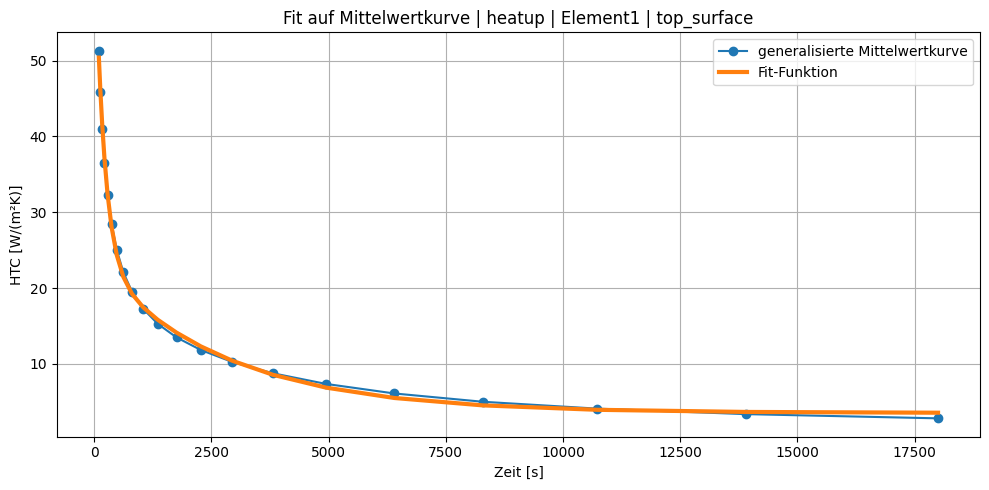

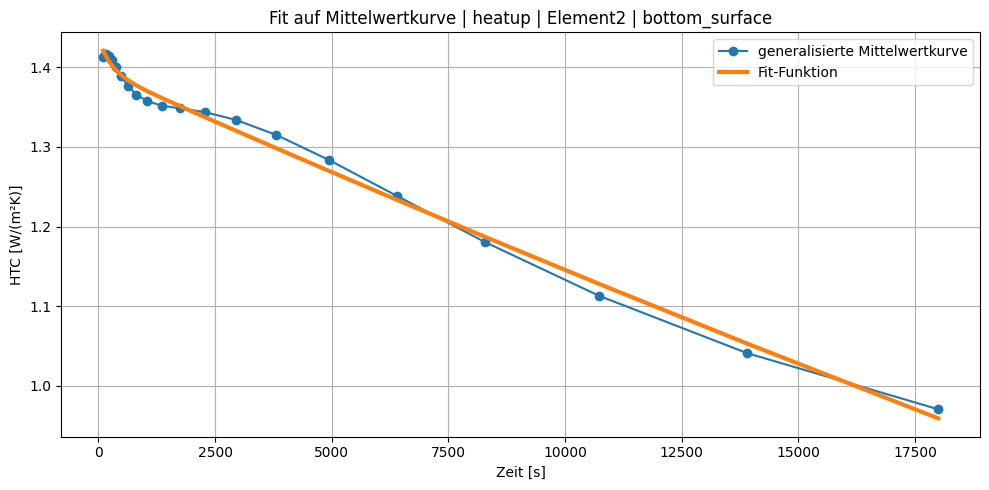

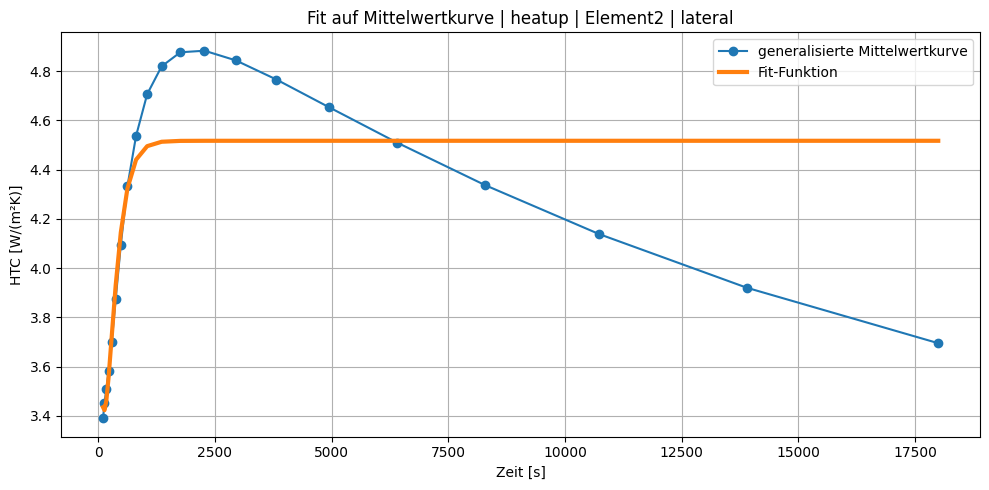

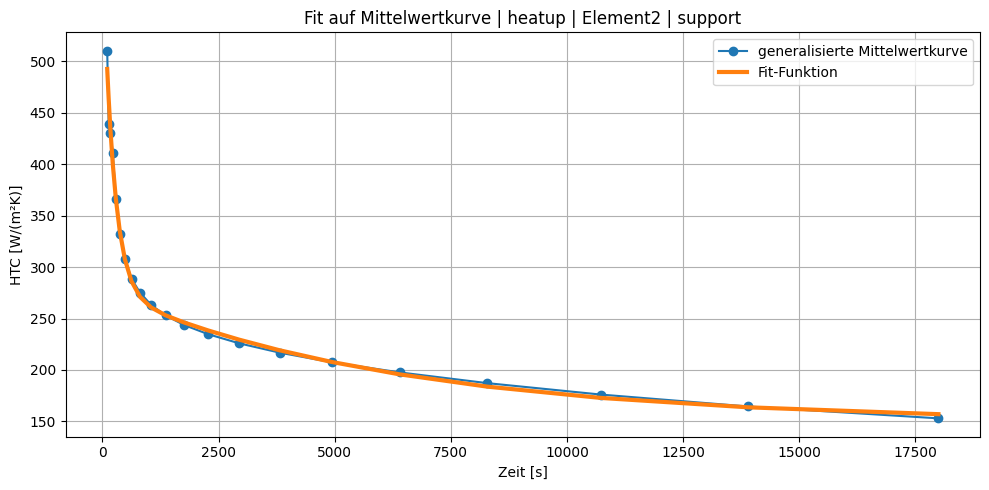

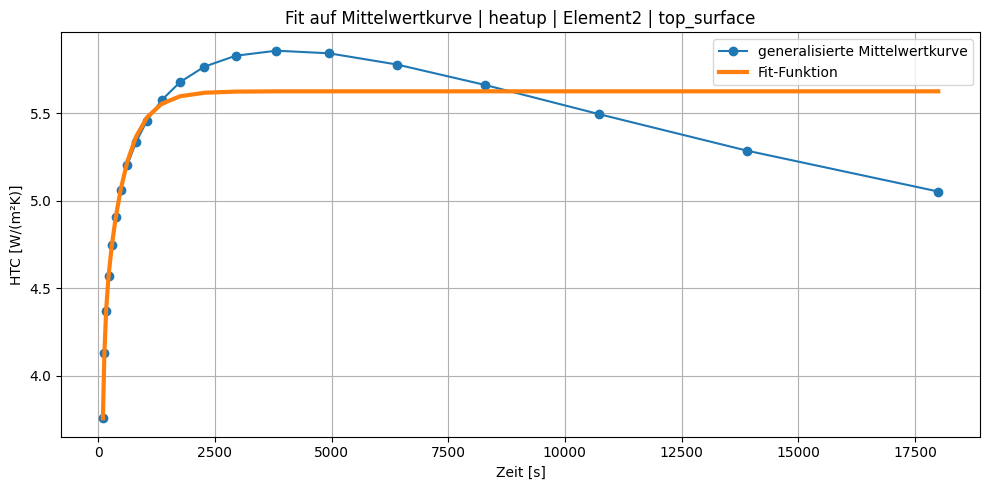

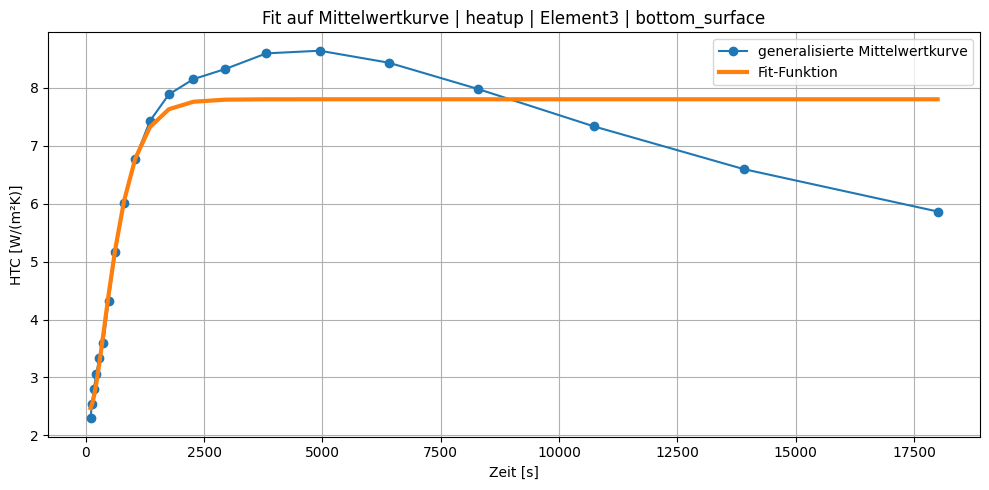

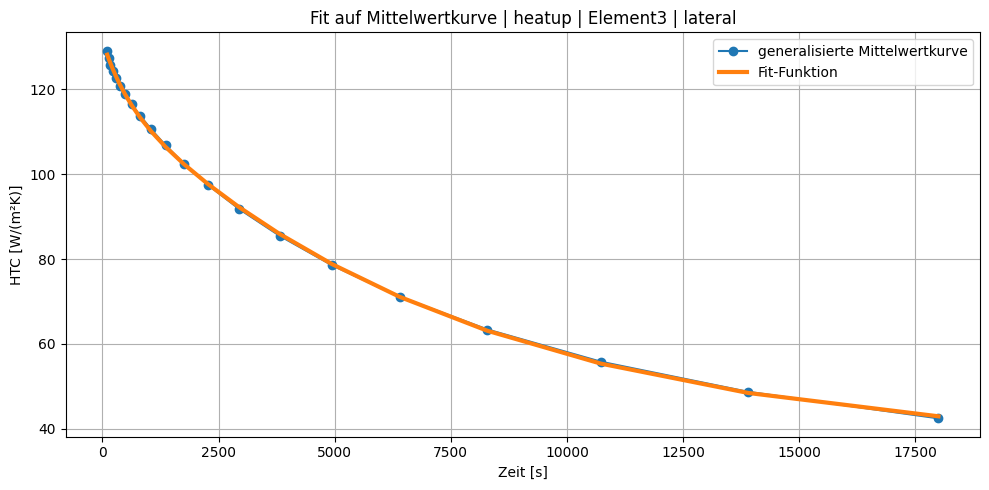

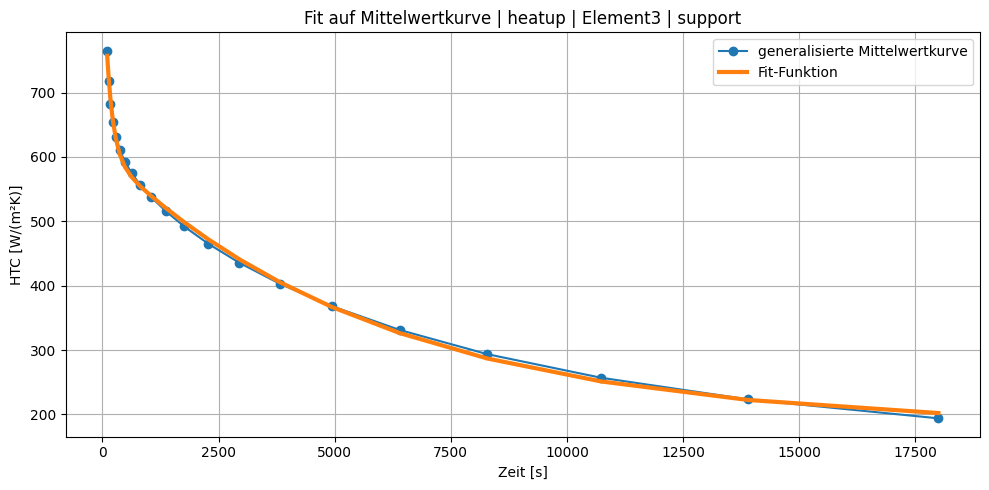

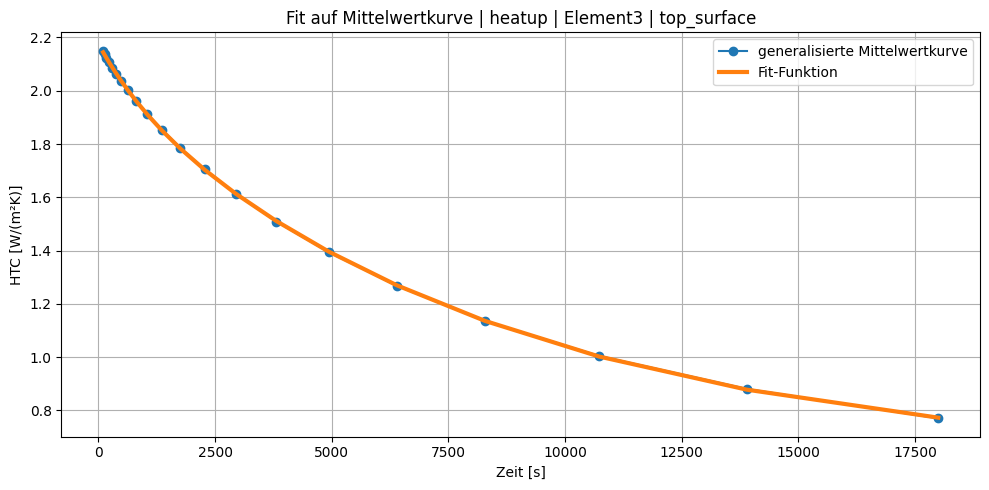

In [9]:
for (phase, element, region), df_group in df_fit_curves.groupby(["phase", "element", "region_group"]):
    
    df_group = df_group.sort_values("time_s")
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(
        df_group["time_s"],
        df_group["htc_mean"],
        marker="o",
        linewidth=1.5,
        label="generalisierte Mittelwertkurve"
    )
    
    plt.plot(
        df_group["time_s"],
        df_group["htc_fit"],
        linewidth=3,
        label="Fit-Funktion"
    )
    
    plt.title(f"Fit auf Mittelwertkurve | {phase} | {element} | {region}")
    plt.xlabel("Zeit [s]")
    plt.ylabel("HTC [W/(m²K)]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 9. Fit Fehler berechnen

In [10]:
fit_error_results = []

for (phase, element, region), df_group in df_fit_curves.groupby(["phase", "element", "region_group"]):
    
    df_group = df_group.dropna(subset=["htc_mean", "htc_fit"]).copy()
    
    if len(df_group) < 3:
        continue
    
    y_true = df_group["htc_mean"].values
    y_pred = df_group["htc_fit"].values
    
    mae_fit = mean_absolute_error(y_true, y_pred)
    mse_fit = mean_squared_error(y_true, y_pred)
    rmse_fit = np.sqrt(mse_fit)
    
    mean_abs_htc = np.mean(np.abs(y_true))
    
    if mean_abs_htc > 0:
        rel_mae_fit = mae_fit / mean_abs_htc * 100
    else:
        rel_mae_fit = np.nan
    
    fit_error_results.append({
        "phase": phase,
        "element": element,
        "region_group": region,
        "MAE_fit": mae_fit,
        "MSE_fit": mse_fit,
        "RMSE_fit": rmse_fit,
        "rel_MAE_fit_%": rel_mae_fit,
        "n_points_fit": len(df_group)
    })

df_fit_errors = pd.DataFrame(fit_error_results)

df_fit_errors["fit_bewertung"] = df_fit_errors["rel_MAE_fit_%"].apply(bewerte_rel_fehler)

display(
    df_fit_errors
    .sort_values(["phase", "element", "region_group"])
)

,phase,element,region_group,MAE_fit,MSE_fit,RMSE_fit,rel_MAE_fit_%,n_points_fit,fit_bewertung
0,cooldown,Element1,bottom_surface,0.011660,0.000331,0.018206,3.327886,21,sehr gut
1,cooldown,Element1,lateral,0.016167,0.000655,0.025586,1.869240,21,sehr gut
2,cooldown,Element1,support,0.099578,0.012166,0.110298,0.143871,21,sehr gut
3,cooldown,Element1,top_surface,0.022674,0.000916,0.030264,3.410277,21,sehr gut
4,cooldown,Element2,bottom_surface,0.018443,0.000644,0.025387,4.837586,21,sehr gut
5,cooldown,Element2,lateral,0.001414,0.000003,0.001697,0.070388,21,sehr gut
6,cooldown,Element2,support,0.042435,0.002454,0.049535,0.055052,21,sehr gut
7,cooldown,Element2,top_surface,0.004779,0.000028,0.005279,0.159361,21,sehr gut
8,cooldown,Element3,bottom_surface,0.069764,0.006824,0.082605,2.926511,21,sehr gut
9,cooldown,Element3,lateral,0.064100,0.005194,0.072072,1.302899,21,sehr gut


# Finale Ergebnistabelle: Generalisierung + Fit-Qualität
für rel_MAE_mean gilt:
< 5 %     → sehr gut
5–15 %    → brauchbar
15–30 %   → kritisch
> 30 %    → nicht gut

In [11]:
df_final_results = (
    df_generalization_summary
    .merge(
        df_fit_results,
        on=["phase", "element", "region_group"],
        how="left"
    )
    .merge(
        df_fit_errors,
        on=["phase", "element", "region_group"],
        how="left"
    )
)

display(
    df_final_results
    .sort_values(["phase", "element", "region_group"])
)

,phase,element,region_group,rel_MAE_mean,rel_MAE_max,MAE_mean,RMSE_mean,n_cases,bewertung,fit_status,...,b2,c,t0,n_points,MAE_fit,MSE_fit,RMSE_fit,rel_MAE_fit_%,n_points_fit,fit_bewertung
0,cooldown,Element1,bottom_surface,2.151717,2.197994,0.007536,0.009773,2,sehr gut,ok,...,0.002327,0.417327,102.0,21,0.011660,0.000331,0.018206,3.327886,21,sehr gut
1,cooldown,Element1,lateral,1.999552,2.007426,0.017293,0.020297,2,sehr gut,ok,...,0.001123,0.918295,102.0,21,0.016167,0.000655,0.025586,1.869240,21,sehr gut
2,cooldown,Element1,support,0.580863,0.584236,0.402022,0.484183,2,sehr gut,ok,...,0.000013,3922.671603,102.0,21,0.099578,0.012166,0.110298,0.143871,21,sehr gut
3,cooldown,Element1,top_surface,6.529930,6.924295,0.043256,0.049061,2,brauchbar,ok,...,0.000751,0.080977,102.0,21,0.022674,0.000916,0.030264,3.410277,21,sehr gut
4,cooldown,Element2,bottom_surface,4.700050,4.780673,0.017913,0.020663,2,sehr gut,ok,...,0.000744,0.074508,102.0,21,0.018443,0.000644,0.025387,4.837586,21,sehr gut
5,cooldown,Element2,lateral,1.733125,1.733806,0.034823,0.040282,2,sehr gut,ok,...,0.000231,0.701019,102.0,21,0.001414,0.000003,0.001697,0.070388,21,sehr gut
6,cooldown,Element2,support,1.511366,1.517587,1.164956,1.350973,2,sehr gut,ok,...,0.000229,27.004057,102.0,21,0.042435,0.002454,0.049535,0.055052,21,sehr gut
7,cooldown,Element2,top_surface,1.119500,1.119664,0.033569,0.038552,2,sehr gut,ok,...,0.000214,0.954955,102.0,21,0.004779,0.000028,0.005279,0.159361,21,sehr gut
8,cooldown,Element3,bottom_surface,17.356441,20.283240,0.401991,0.573232,2,kritisch,ok,...,0.000452,0.438626,102.0,21,0.069764,0.006824,0.082605,2.926511,21,sehr gut
9,cooldown,Element3,lateral,10.355648,11.416782,0.504125,0.672053,2,brauchbar,ok,...,0.000472,1.055114,102.0,21,0.064100,0.005194,0.072072,1.302899,21,sehr gut


# Kritische / schlechte Generalisierungen anzeigen

In [12]:
df_kritisch = df_final_results[
    df_final_results["bewertung"].isin(["kritisch", "nicht gut"])
].copy()

display(
    df_kritisch
    .sort_values(["phase", "rel_MAE_mean"], ascending=[True, False])
)

,phase,element,region_group,rel_MAE_mean,rel_MAE_max,MAE_mean,RMSE_mean,n_cases,bewertung,fit_status,...,b2,c,t0,n_points,MAE_fit,MSE_fit,RMSE_fit,rel_MAE_fit_%,n_points_fit,fit_bewertung
8,cooldown,Element3,bottom_surface,17.356441,20.283240,0.401991,0.573232,2,kritisch,ok,...,0.000452,0.438626,102.0,21,0.069764,0.006824,0.082605,2.926511,21,sehr gut
13,heatup,Element1,lateral,82.269406,171.859970,3.503987,5.994079,5,nicht gut,ok,...,0.001247,0.613391,102.0,21,0.136008,0.023425,0.153052,2.018186,21,sehr gut
20,heatup,Element3,bottom_surface,66.098106,142.094823,3.142726,3.566189,5,nicht gut,ok,...,0.003118,7.802965,102.0,21,0.392993,0.372532,0.610354,6.595246,21,brauchbar
16,heatup,Element2,bottom_surface,30.717655,54.858793,0.362983,0.399230,5,nicht gut,ok,...,0.000008,-1.758453,102.0,21,0.008346,0.000089,0.009456,0.637898,21,sehr gut
15,heatup,Element1,top_surface,27.816776,47.807254,4.930686,7.720665,5,kritisch,ok,...,0.000362,3.530944,102.0,21,0.456002,0.256656,0.506613,2.348991,21,sehr gut
17,heatup,Element2,lateral,24.480882,40.834810,0.929199,1.295807,5,kritisch,ok,...,0.006303,4.517169,102.0,21,0.205571,0.086511,0.294127,4.871188,21,sehr gut
12,heatup,Element1,bottom_surface,15.100868,35.625822,0.539395,0.634677,5,kritisch,ok,...,0.000582,0.176702,102.0,21,0.067464,0.006280,0.079249,1.779744,21,sehr gut



# Ergebnisse speichern


df_final_results.to_csv("final_htc_results.csv", index=False)  
df_kritisch.to_csv("kritische_htc_regionen.csv", index=False)  

print("Gespeichert:")  
print("- final_htc_results.csv")  
print("- kritische_htc_regionen.csv")  